# NB1 · Data Profiling & Quality

**Goal**: Understand what we have before we analyse anything.  
This notebook answers: How many rows/columns? What types? Are there nulls? What do the distributions look like?

Download the dataset from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Save the CSV as `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same folder as this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: 7,043 rows × 21 columns


## 1 · Column inventory

Print each column, its dtype, and a few sample values so we know what we're working with.

In [2]:
inventory = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'unique':  df.nunique(),
    'sample':  [df[c].dropna().unique()[:3].tolist() for c in df.columns]
})
inventory

,dtype,nulls,unique,sample
customerID,object,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK]"
gender,object,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,object,0,2,"[Yes, No]"
Dependents,object,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2]"
PhoneService,object,0,2,"[No, Yes]"
MultipleLines,object,0,3,"[No phone service, No, Yes]"
InternetService,object,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,0,3,"[No, Yes, No internet service]"


## 2 · Fix known data-quality issues

`TotalCharges` is shipped as an object column because some entries are blank strings.  
We coerce to numeric — blank rows (≈11) represent new customers with 0 tenure, so we fill with 0.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"NaN in TotalCharges before fill: {df['TotalCharges'].isna().sum()}")
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Binary-encode Churn for numeric analysis
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)
print('\nChurn distribution:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

NaN in TotalCharges before fill: 11

Churn distribution:
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


## 3 · Numeric distributions

We have three key numeric columns: `tenure`, `MonthlyCharges`, `TotalCharges`.  
Plotting them split by churn reveals whether churners look different right away.

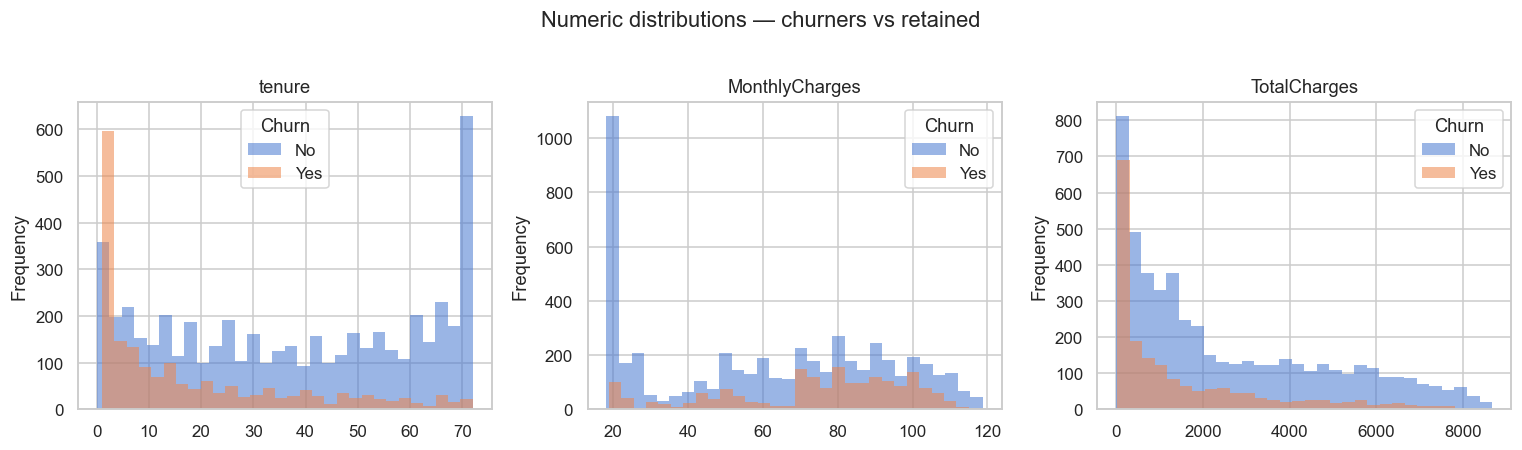

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.4,1679.5
Yes,10.0,79.6,703.6


In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby('Churn'):
        grp[col].plot.hist(ax=ax, bins=30, alpha=0.55, label=label, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(title='Churn')
plt.suptitle('Numeric distributions — churners vs retained', y=1.02)
plt.tight_layout()
plt.show()

# Quick stats
df.groupby('Churn')[num_cols].median().round(1)

## 4 · Categorical column breakdown

Check value counts for all categorical columns.  
Flag any suspiciously small categories that might need grouping.

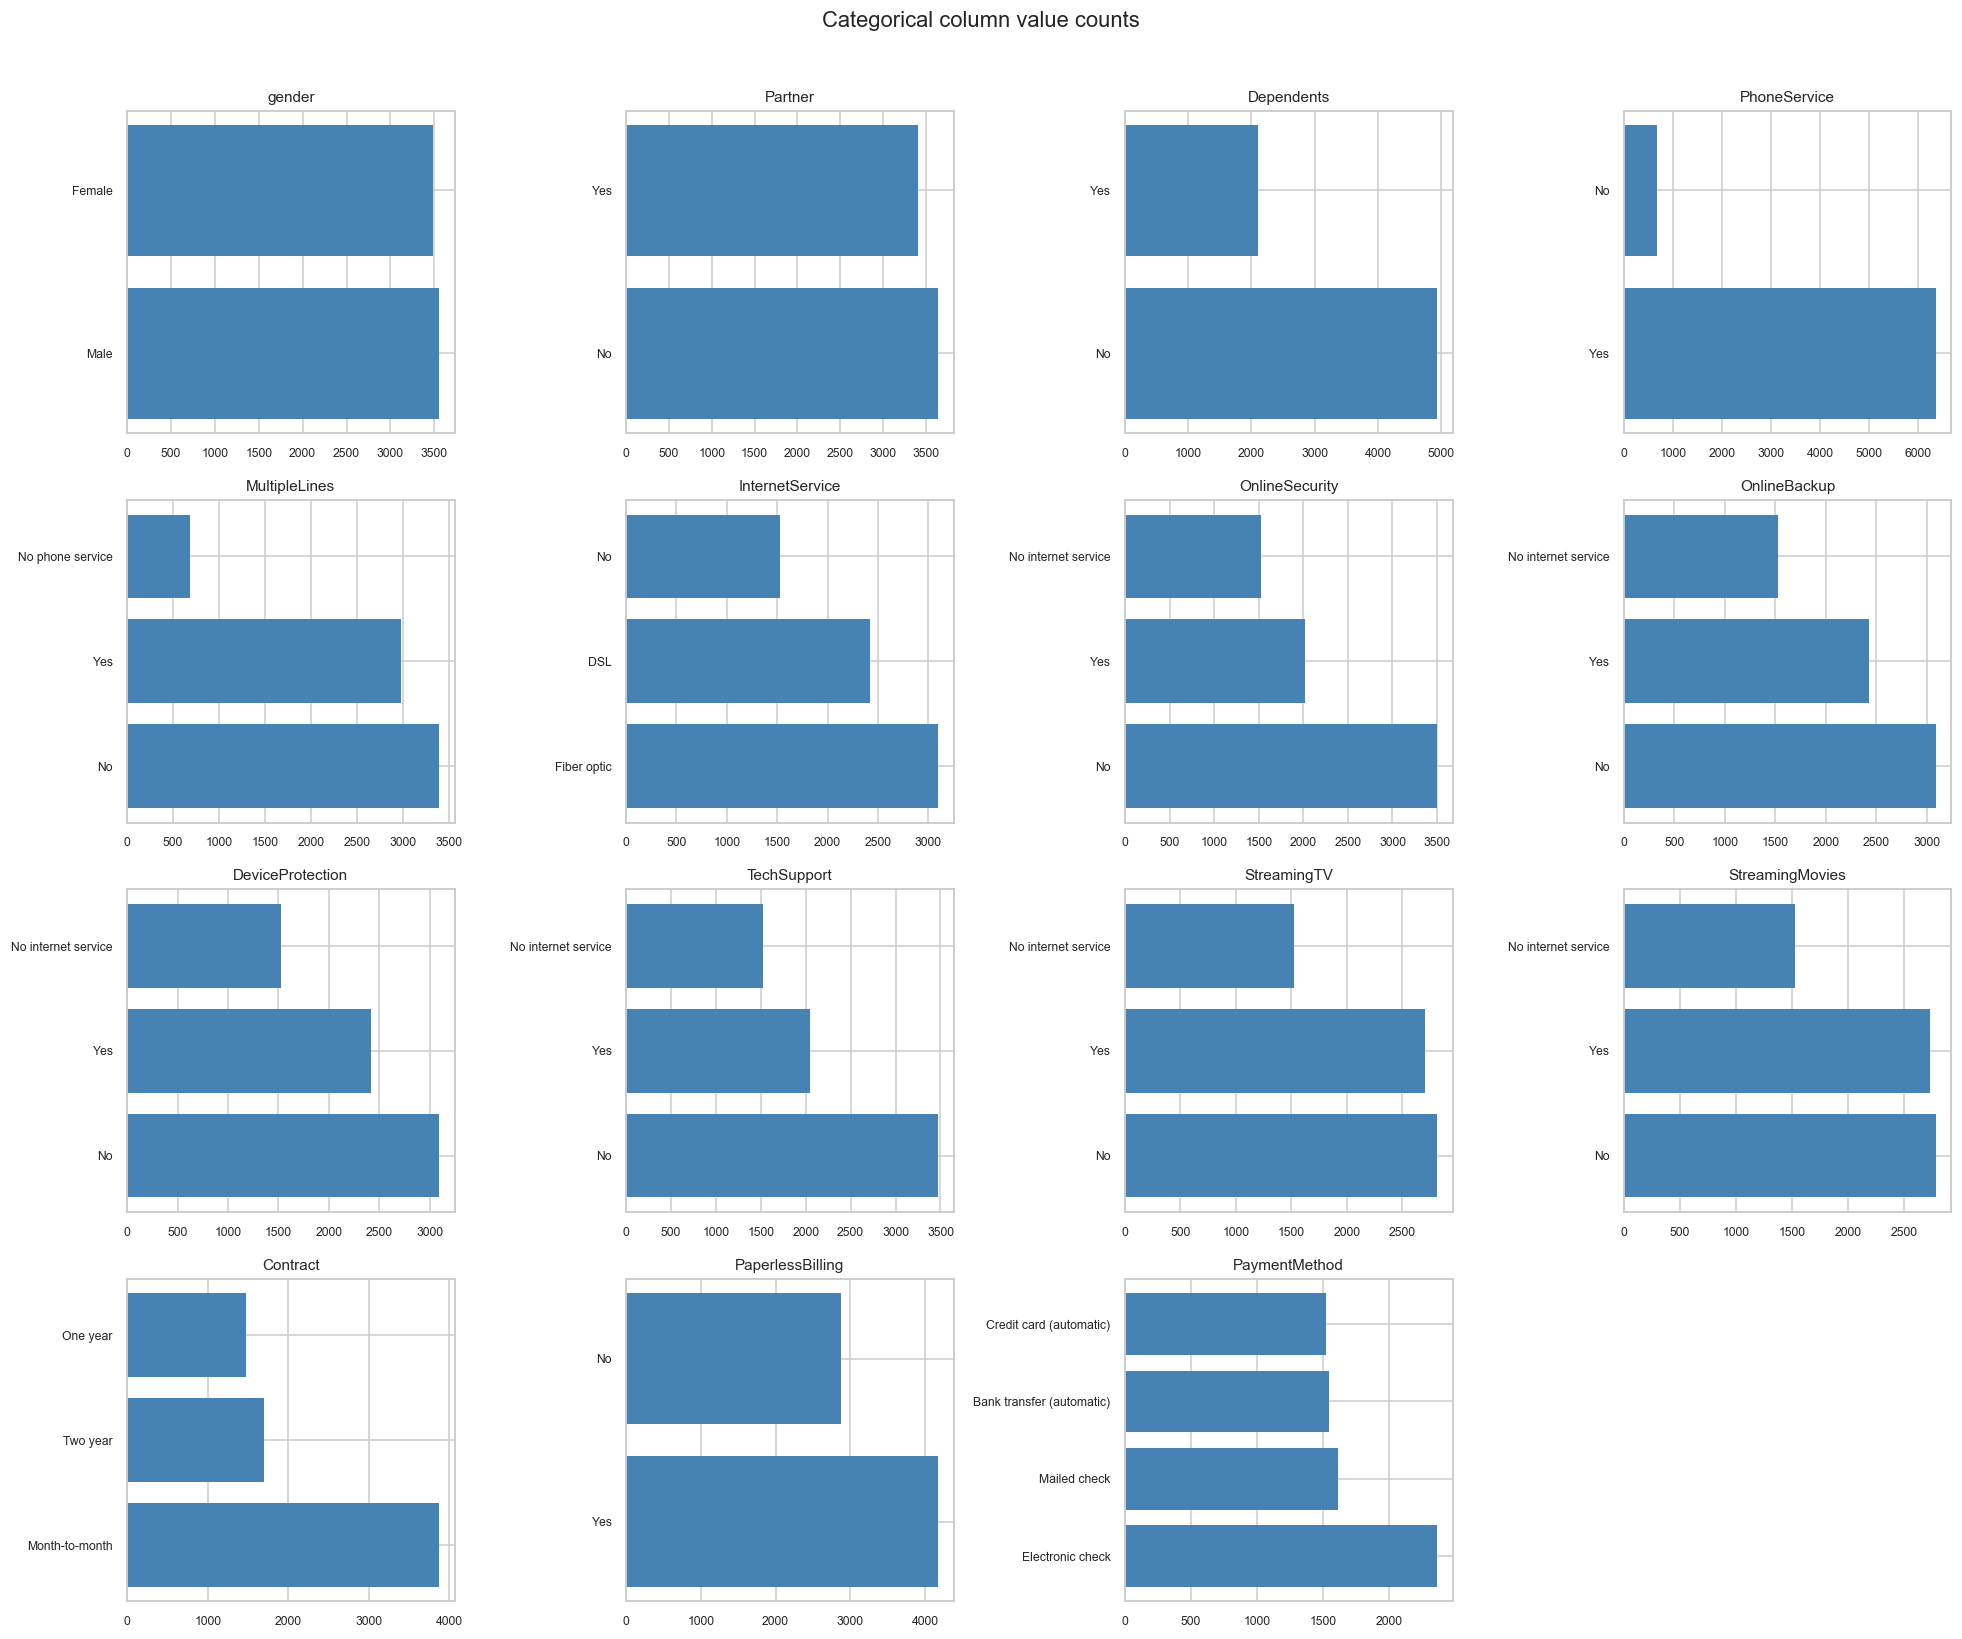

In [5]:
cat_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical column value counts', y=1.01)
plt.tight_layout()
plt.show()

## 5 · Correlation heatmap (numerics)

`tenure` and `TotalCharges` are highly correlated (obviously — longer customers pay more).  
This will matter when we build features later.

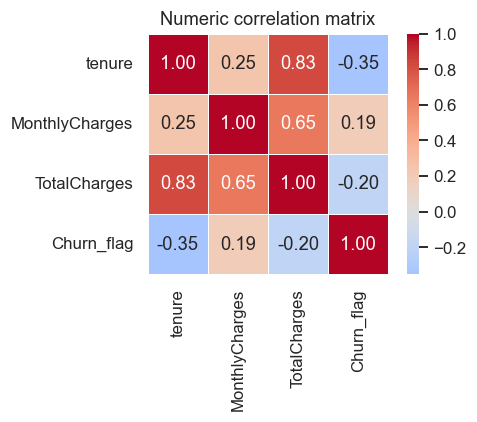

In [6]:
corr = df[num_cols + ['Churn_flag']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Numeric correlation matrix')
plt.tight_layout()
plt.show()

## 6 · Summary & export

Save the clean dataframe so subsequent notebooks start from the same state.

In [7]:
df.to_csv('telco_clean.csv', index=False)
print('Saved telco_clean.csv')
print(f'\nFinal shape: {df.shape}')
print(f'Overall churn rate: {df["Churn_flag"].mean():.1%}')

Saved telco_clean.csv

Final shape: (7043, 22)
Overall churn rate: 26.5%
